In [1]:
import os

os.environ["LD_LIBRARY_PATH"]="$HOME/anaconda3/envs/mpd-splines-public/lib" #:$LD_LIBRARY_PATH
os.environ["CPATH"]="$HOME/anaconda3/envs/mpd-splines-public/include"

# unset LD_PRELOAD to use conda libstdc
os.environ.pop("LD_PRELOAD", None)

In [2]:
from pathlib import Path

import click

import isaacgym

from pprint import pprint


from dotmap import DotMap
import h5py
import seaborn

from mpd.parametric_trajectory.trajectory_bspline import ParametricTrajectoryBspline
from mpd.paths import DATASET_BASE_DIR
from pb_ompl.pb_ompl import fit_bspline_to_path
from torch_robotics.isaac_gym_envs.motion_planning_envs import (
    MotionPlanningIsaacGymEnv,
    MotionPlanningControllerIsaacGym,
)
from scripts.generate_data.generate_trajectories import GenerateDataOMPL

import matplotlib.pyplot as plt

import os.path

import numpy as np
import torch
import yaml
from scipy import interpolate
import itertools
#from mpd.utils.loaders import load_params_from_yaml
from mpd.utils.loaders import get_planning_task_and_dataset, load_params_from_yaml, save_to_yaml
from torch_robotics import environments, robots
from torch_robotics.tasks.tasks import PlanningTask
from torch_robotics.torch_kinematics_tree.utils.files import get_robot_path
from torch_robotics.torch_utils.seed import fix_random_seed
from torch_robotics.torch_utils.torch_utils import DEFAULT_TENSOR_ARGS, to_torch, to_numpy, get_torch_device
from torch_robotics.visualizers.plot_utils import create_fig_and_axes, plot_multiline

import torch.nn.functional as F

from bspline_split_test import split_curve_scipy
from bspline_merge_test import load_spline, get_new_control_point

Importing module 'gym_38' (/home/sisrel/pjw/mpd-splines-public/deps/isaacgym/python/isaacgym/_bindings/linux-x86_64/gym_38.so)
Setting GYM_USD_PLUG_INFO_PATH to /home/sisrel/pjw/mpd-splines-public/deps/isaacgym/python/isaacgym/_bindings/linux-x86_64/usd/plugInfo.json


pybullet build time: Nov 28 2023 23:51:11
<frozen importlib._bootstrap>:219: RuntimeWarning: to-Python converter for std::vector<unsigned long, std::allocator<unsigned long> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:219: RuntimeWarning: to-Python converter for std::vector<std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >, std::allocator<std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:219: RuntimeWarning: to-Python converter for std::vector<int, std::allocator<int> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:219: RuntimeWarning: to-Python converter for std::vector<double, std::allocator<double> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:219: RuntimeWarning: to-Python converter for Eigen::Ref<Eigen::Matrix<double,

PyTorch version 2.0.0+cu118
Device count 1
/home/sisrel/pjw/mpd-splines-public/deps/isaacgym/python/isaacgym/_bindings/src/gymtorch


Using /home/sisrel/.cache/torch_extensions/py38_cu118 as PyTorch extensions root...
Emitting ninja build file /home/sisrel/.cache/torch_extensions/py38_cu118/gymtorch/build.ninja...
Building extension module gymtorch...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


ninja: no work to do.


Loading extension module gymtorch...



-------------- ARGS --------------
bspline_degree: 5
bspline_num_control_points: 30
bspline_zero_acc_at_start_and_goal: true
bspline_zero_vel_at_start_and_goal: true
cfg_file: None
debug: false
device: cpu
env_id: EnvSimple2D
fit_bspline: false
git_hash: 7609ba54c718524c89f529a15a0016706fbb79bb
git_url: git@github.com:jacarvalho/mpd-splines.git
interpolate_num: 256
min_distance_robot_env: 0.01
n_parallel_jobs: 1
num_trajectories_desired: 10000
num_trajectories_generated: 10000
num_trajectories_per_task: 1
planner: RRTConnect
planner_allowed_time: 10.0
robot_id: RobotPointMass2D
sample_joint_position_goals_with_same_ee_pose: false
selection: one
simplify_path: true

Computing the SDF grid and gradients of FIXED objects took: 0.079 sec
-----------------------------------
Torchkin robot: pointmass2d
Num links: 5
DOF: 2

-----------------------------------
long scale : tensor(0.1984, device='cuda:0')
[3672]

Fitting B-spline
u shape: (256,)
knots shape: (36,)
coefficients shape: (2, 30)
[

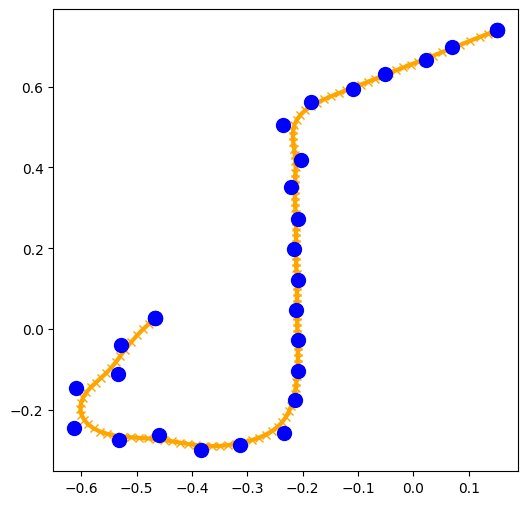

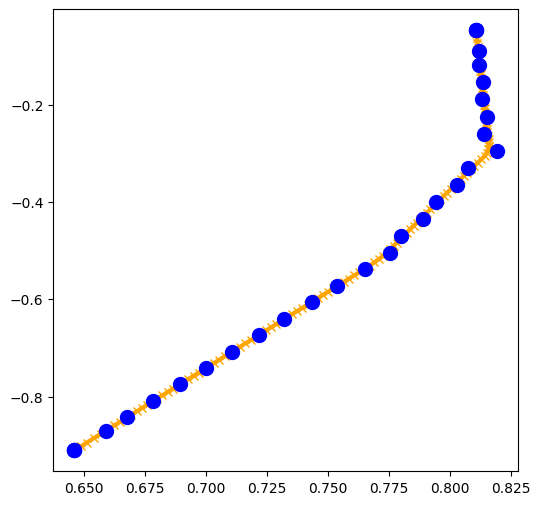

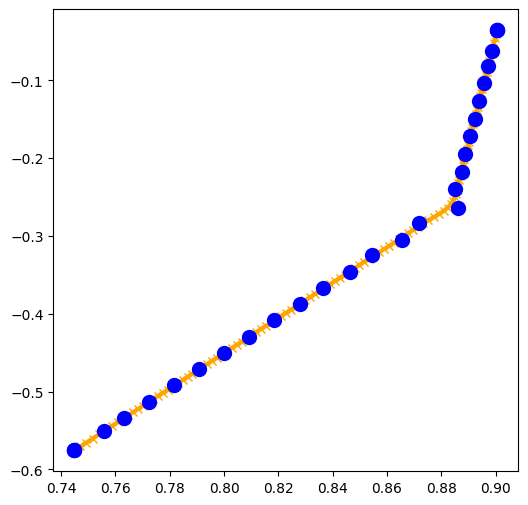

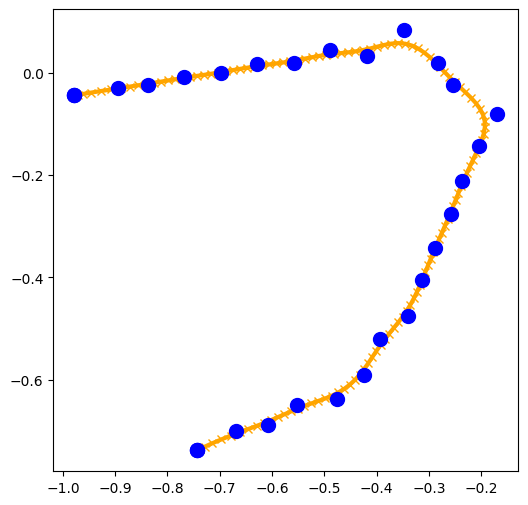

In [3]:
data_dir = Path(DATASET_BASE_DIR) / "EnvSimple2D-RobotPointMass2D-joint_joint-one-RRTConnect"
device = "cuda:0"
device = get_torch_device(device)
tensor_args = {"device": device, "dtype": torch.float32}

bspl_l, q_trajs_d, planning_task = load_spline(data_dir)
q_trajs_pos_ref = q_trajs_d["pos"]
q_trajs_vel_ref = q_trajs_d["vel"]
q_trajs_acc_ref = q_trajs_d["acc"]

#prob = [[0.0, 0.44], [0.44, 0.88]]
prob = [[0.0, 0.44], [0.32, 0.76]] # 3 * 0.04 => 3+1 = 4 overlaps
partial_dur = 5.0 * 0.44 # len 16
num_T_pts = 60

task_id = 0

In [4]:
left = split_curve_scipy(bspl_l[task_id],prob[0][0], prob[0][1])
right = split_curve_scipy(bspl_l[task_id],prob[1][0], prob[1][1])
ans_spline = split_curve_scipy(bspl_l[task_id],prob[0][0], prob[1][1])
print(f"{len(left.c)}, {len(right.c)}, {len(ans_spline.c)}")
print(left.c[-8:])
print(right.c[:8])
print(ans_spline.c[10:20])

16, 16, 24
[[-0.459 -0.262]
 [-0.383 -0.3  ]
 [-0.312 -0.286]
 [-0.234 -0.257]
 [-0.218 -0.192]
 [-0.212 -0.148]
 [-0.21  -0.118]
 [-0.21  -0.103]]
[[-0.311 -0.282]
 [-0.297 -0.277]
 [-0.268 -0.266]
 [-0.23  -0.24 ]
 [-0.214 -0.176]
 [-0.208 -0.104]
 [-0.209 -0.027]
 [-0.212  0.047]]
[[-0.312 -0.286]
 [-0.234 -0.257]
 [-0.214 -0.176]
 [-0.208 -0.104]
 [-0.209 -0.027]
 [-0.212  0.047]
 [-0.209  0.122]
 [-0.215  0.199]
 [-0.208  0.271]
 [-0.221  0.351]]


In [5]:
n_ovlp = 4
spline_l = []
scipy_l = []
new_q_cps = []
q_cps_all = []
q_trajs_pos_all = []
q_trajs_vel_all = []
q_trajs_acc_all = []
for i,p in enumerate(prob) : 
    tmp_spline = split_curve_scipy(bspl_l[task_id], p[0], p[1])
    #scipy_l.append(tmp_spline)
    new_q_cps = to_torch(tmp_spline.c, **tensor_args)
    tmp_traj = ParametricTrajectoryBspline(
        n_control_points=len(new_q_cps),
        degree=5,
        num_T_pts=num_T_pts,
        zero_vel_at_start_and_goal=False,
        zero_acc_at_start_and_goal=False,
        remove_outer_control_points=False,
        keep_last_control_point=False,
        trajectory_duration=partial_dur,
        tensor_args=tensor_args,
        phase_time_class="PhaseTimeLinear",
    )
    spline_l.append(tmp_traj)
    # create interpolate.BSpline from bspline (normalized knots)
    scipy_l.append(interpolate.BSpline( t = tmp_traj.bspline.u,
                                       c = tmp_spline.c, 
                                       k = tmp_traj.bspline.d))
    scale = tmp_traj.phase_time.rs[0] # same for right
    if i == 1 : 
        h = 1.0 / (tmp_traj.bspline.m - 2 * tmp_traj.bspline.d)
        T = tmp_traj.bspline.num_T_pts
        new_right_cps = get_new_control_point(q_trajs_pos_all[-1][0,-1,:], 
                                            q_trajs_vel_all[-1][0,-1,:]/scale, 
                                            q_trajs_acc_all[-1][0,-1,:]/(scale*scale),
                                                h, T)

        new_q_cps[:3] = new_right_cps["left"].T

    # # add noise 
    # if i == 0 : 
    #     new_q_cps[-n_ovlp:] = new_q_cps[-n_ovlp:] + torch.randn_like(new_q_cps[-n_ovlp:]) * 0.01
    # else : 
    #     new_q_cps[:n_ovlp] = new_q_cps[:n_ovlp] + torch.randn_like(new_q_cps[:n_ovlp]) * 0.01
        
    q_cps_all.append(to_numpy(new_q_cps)) 
    q_trajs_d = tmp_traj.get_q_trajectory_in_phase(new_q_cps, get_type=("pos","vel","acc"))
    #scale = 0.5850 # 3/5 * 39/40
    #scale = 1.0 / tmp_traj.trajectory_duration
    q_trajs_pos = q_trajs_d["pos"] 
    q_trajs_vel = q_trajs_d["vel"] * scale
    q_trajs_acc = q_trajs_d["acc"] * (scale * scale)

    q_trajs_pos_all.append(q_trajs_pos.unsqueeze(0))
    q_trajs_vel_all.append(q_trajs_vel.unsqueeze(0))
    q_trajs_acc_all.append(q_trajs_acc.unsqueeze(0))

q_trajs_pos_all = to_numpy(torch.cat(q_trajs_pos_all, axis = 0))
q_trajs_vel_all = to_numpy(torch.cat(q_trajs_vel_all, axis = 0))
q_trajs_acc_all = to_numpy(torch.cat(q_trajs_acc_all, axis = 0))

ValueError: x and y must have same first dimension, but have shapes (106,) and (60,)

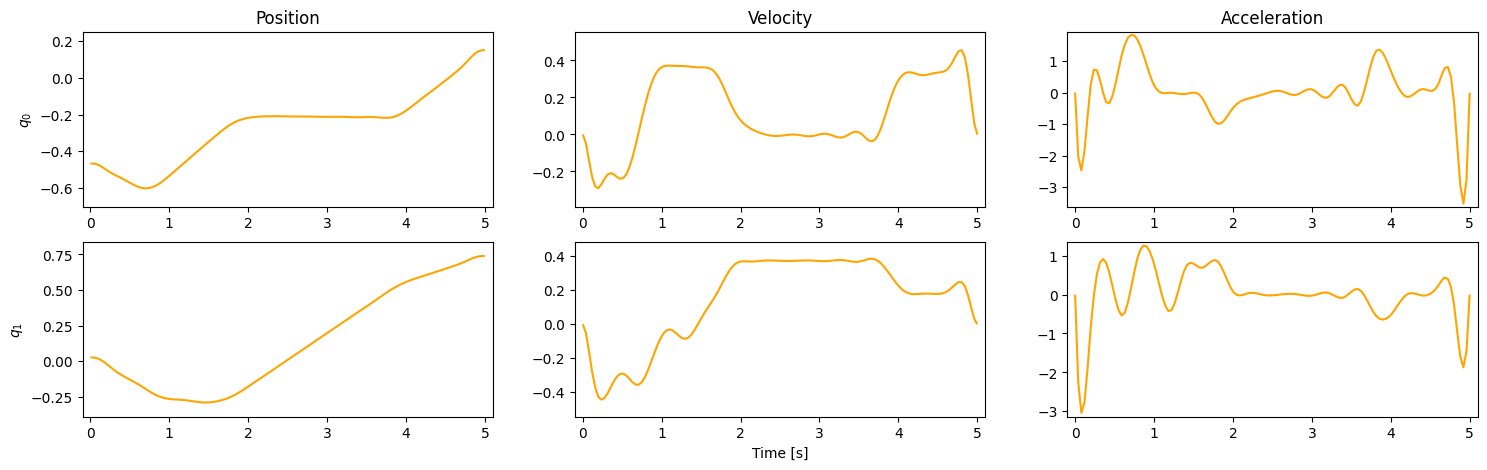

In [10]:
colors = ['red', 'green', 'blue', 'orange']

fig, axs = planning_task.plot_joint_space_trajectories(
    q_pos_trajs=q_trajs_pos_ref[task_id].unsqueeze(0),
    q_vel_trajs=q_trajs_vel_ref[task_id].unsqueeze(0),
    q_acc_trajs=q_trajs_acc_ref[task_id].unsqueeze(0),
    # control_points=control_points_concat,
    set_q_pos_limits=False,
    set_q_vel_limits=False,
    set_q_acc_limits=False,
)
h = 1.0 / (spline_l[-1].bspline.m - 2 * spline_l[-1].bspline.d)
T = spline_l[-1].bspline.num_T_pts
scale = spline_l[-1].phase_time.rs[0]
t_start = 0
t_goal = 4.2

# fig, axs = plt.subplots(dim, 3, squeeze=False, figsize=(18, 2.5 * dim))

# axs[0, 0].set_title("Position")
# axs[0, 1].set_title("Velocity")
# axs[0, 2].set_title("Acceleration")
# axs[-1, 1].set_xlabel("Time [s]")

partial_dur * len(prob)
dt = partial_dur / (num_T_pts-1)
dt_merged = partial_dur * 2 / (2* num_T_pts-1)
# Positions, velocities, accelerations
q_trajs_filtered = (q_trajs_pos_all, q_trajs_vel_all, q_trajs_acc_all)

for i, ax in enumerate(axs):
    for j, q_trajs_filtered_item in enumerate(q_trajs_filtered):
        for i_hz in range(len(prob)) :
            #tmp_timesteps = 5 * prob[i_hz][0] + dt*(np.arange(num_T_pts))
            tmp_timesteps = 2.0 * i_hz + dt*(np.arange(num_T_pts))
            ax[j].plot(tmp_timesteps, q_trajs_filtered_item[i_hz,:,i], c = colors[i_hz], linestyle="solid")
        # plot merged spline
        #tmp_timesteps = 5 * prob[0][0] + dt_merged*(np.arange(num_T_pts*2))
        #ax[j].plot(tmp_timesteps, q_trajs_merged[j][:,i], c = colors[0], linestyle="solid")
    ax[0].set_ylabel(f"$q_{i}$")

t_eps = 0.1
for ax in list(itertools.chain(*axs)):
    ax.set_xlim(t_start - t_eps, t_goal + t_eps)


In [25]:
from mpd.parametric_trajectory.trajectory_bspline import BSpline
# prob = [[0.0, 0.44], [0.24, 0.68]] # 6 overlaps
# # assume 16 control points
# # set num_T_pts so that t_l exist for t ?
# num_T_pts = 128
# n_pts = 16
# final_spl = BSpline(n_pts, degree=5, num_T_pts=num_T_pts, device = device)
#device = "cuda:0"
device = "cpu"
device = get_torch_device(device)
tensor_args = {"device": device, "dtype": torch.float32}
sml_num_T_pts = 56 # (sml_n_pts - k ) * 5 + 1
sml_n_pts = 16
n_pts = 16 + 16 -6
num_T_pts = 106 # (sml_n_pts - k + sml_n_pts - k - 1) * 5 + 1 # span overlap 1

# two cps given 

l_cps = to_torch(q_cps_all[0], **tensor_args) # len sml_n_pts
r_cps = to_torch(q_cps_all[1], **tensor_args) # len sml_n_pts
dim = l_cps.shape[-1]
full_cps = torch.zeros((n_pts, dim), **tensor_args)
full_cps[:sml_n_pts] = to_torch(l_cps, **tensor_args)                      # indices 0..15
full_cps[sml_n_pts:] = to_torch(r_cps[6:], **tensor_args)                  # indices 16..25

# final_spl = BSpline(n_pts, degree=5, num_T_pts=num_T_pts, device=device)
# sml_spl = BSpline(sml_n_pts, degree=5, num_T_pts=sml_num_T_pts, device=device)
partial_dur = 2.2 # 5 * 0.44

final_traj = ParametricTrajectoryBspline(
        n_control_points=n_pts,
        degree=5,
        num_T_pts=num_T_pts,
        zero_vel_at_start_and_goal=False,
        zero_acc_at_start_and_goal=False,
        remove_outer_control_points=False,
        keep_last_control_point=False,
        trajectory_duration=partial_dur*21/11, # 4.2
        tensor_args=tensor_args,
        phase_time_class="PhaseTimeLinear",
    )

sml_traj = ParametricTrajectoryBspline(
        n_control_points=sml_n_pts,
        degree=5,
        num_T_pts=sml_num_T_pts,
        zero_vel_at_start_and_goal=False,
        zero_acc_at_start_and_goal=False,
        remove_outer_control_points=False,
        keep_last_control_point=False,
        trajectory_duration=partial_dur,
        tensor_args=tensor_args,
        phase_time_class="PhaseTimeLinear",
    )

final_spl = final_traj.bspline
sml_spl = sml_traj.bspline

#print(l_cps, r_cps)
# -------------------------------------------------------------------------
# 1) Boundaries where C² constraints are applied
# -------------------------------------------------------------------------

j0 = 10       # example start index of 6 new CPs 

overlap_idx = torch.arange(j0, j0+6) # cps index for merged spline

# select t_l, t_r
# print("t_L range",final_spl.u[j0],final_spl.u[j0+1]) # 5/21 , 6/21
# print("t_r range",final_spl.u[j0+10], final_spl.u[j0+11]) # 15/21, 16/21
# assert t_l <= final_spl.u[

k_join = j0 + 5 # middle point 0 ~ 11 
k_l = k_r = k_join
#t_L = 0.5 * (final_spl.u[k_join] + final_spl.u[k_join+1])
t_L = final_spl.u[k_join]
print("t_L range",final_spl.u[k_join],final_spl.u[k_join+1]) #10/21. 11/21
t_L = (final_spl.u[k_join] + final_spl.u[k_join+1])/2
t_R = t_L

# # t_L = 

# # s_a = 6/11 # -6 th 
# # s_b = 5/11 # 6 th 
# a = 6/21 # should be in t_l range 
# b = 15/21 # should be in t_r range (right inclusive)
# # find spans containing a and b

# # print(final_spl.u)

# k_l = np.where(np.isclose(final_spl.u, a))[0].min()
# k_r = np.where(np.isclose(final_spl.u, b))[0].min()

# assert np.isclose(a, final_spl.u[k_l]) and np.isclose(b, final_spl.u[k_r])
# print(f'{k_l=}, {k_r=}')
# # sample parameters
# T = np.linspace(0.0, 1.0, num_T_pts)
# t_l_idx = np.searchsorted(T, a, side='left')
# t_r_idx = np.searchsorted(T, b, side='left')
# #print(t_l_idx, t_r_idx, T[t_l_idx], T[t_r_idx])
T = np.linspace(0.0, 1.0, num_T_pts)
t_l_idx = np.searchsorted(T, t_L, side='left')
t_r_idx = np.searchsorted(T, t_R, side='left')
print(t_l_idx, t_r_idx, T[t_l_idx], T[t_r_idx])
t_l = to_torch(T[t_l_idx], **tensor_args)  # param value (float)
t_r = to_torch(T[t_r_idx], **tensor_args)  # param value (float)

#assert np.isclose(t_l, a) and np.isclose(t_r, b)
#assert np.isclose(t_l, t_L) and np.isclose(t_r, t_R)

print(t_l_idx, t_r_idx, t_l, t_r) 
# t_sl = to_torch(t_sl, device= device, dtype=torch.long)
# t_sr = to_torch(t_sr, device= device, dtype=torch.long)

# convert to span of small spline
t_sl = to_numpy((21/11) * t_l) # 6/11 10/11
t_sr = to_numpy((21 * t_r - 10)/11) # (15-10) / (21 - 10) = 5/11 0

print(f'{t_sl=}, {t_sr=}')
# references from original trajectories
# modify t_l, t_r to follow index of left and right splines (t_sl, t_sr)
T_s = np.linspace(0.0, 1.0, sml_num_T_pts)
# k_sl = np.where(np.isclose(sml_spl.u, t_sl))[0].min()
# k_sr = np.where(np.isclose(sml_spl.u, t_sr))[0].max() if t_sr == 0 else np.where(np.isclose(sml_spl.u, t_sr))[0].min() 

#k_sr = np.where(np.isclose(sml_spl.u, t_sr))[0].min() 
#print(f'{k_sl=}, {k_sr=}, {t_sl=}, {t_sr=}, {sml_spl.u[k_sl]=}, {sml_spl.u[k_sr]=}')
#t_sl_idx = np.searchsorted(T_s, t_sl) # find closest
#t_sr_idx = np.searchsorted(T_s, t_sr) # find closest
t_sl_idx =  np.abs(T_s - t_sl).argmin()
t_sr_idx =  np.abs(T_s - t_sr).argmin()

assert np.abs(T_s[t_sl_idx] - t_sl) < 1e-3 and np.abs(T_s[t_sr_idx] - t_sr) < 1e-4 
print(t_sl_idx, t_sr_idx, T_s[t_sl_idx], T_s[t_sr_idx])
# left 
sml_scale = sml_traj.phase_time.rs[0]
scale = final_traj.phase_time.rs[0]
print(sml_scale, scale)
q_trajs_d_l = sml_traj.get_q_trajectory_in_phase(l_cps, get_type=("pos","vel","acc"))
q_trajs_d_r = sml_traj.get_q_trajectory_in_phase(r_cps, get_type=("pos","vel","acc"))
# q_trajs_pos = q_trajs_d["pos"] 
# q_trajs_vel = q_trajs_d["vel"] #* scale
# q_trajs_acc = q_trajs_d["acc"] #* (scale * scale)

# ref_l = dict(
#     pos = to_torch(q_trajs_pos_all[0, k_sl, :], **tensor_args),
#     vel = to_torch(q_trajs_vel_all[0, k_sl, :], **tensor_args),
#     acc = to_torch(q_trajs_acc_all[0, k_sl, :], **tensor_args),
# )
# ref_r = dict(
#     pos = to_torch(q_trajs_pos_all[1, k_sr, :], **tensor_args),
#     vel = to_torch(q_trajs_vel_all[1, k_sr, :]/scale, **tensor_args),
#     acc = to_torch(q_trajs_acc_all[1, k_sr, :]/(scale*scale), **tensor_args),
# )
ref_l = dict(pos = q_trajs_d_l["pos"][t_sl_idx, :], 
             vel=q_trajs_d_l["vel"][t_sl_idx, :] * sml_scale / scale, # small phase to time to merged phase
             acc=q_trajs_d_l["acc"][t_sl_idx,:] * sml_scale * sml_scale / (scale * scale), 
            )
ref_r = dict(pos = q_trajs_d_r["pos"][t_sr_idx, :], 
             vel=q_trajs_d_r["vel"][t_sr_idx, :] * sml_scale / scale , 
             acc=q_trajs_d_r["acc"][t_sr_idx,:] * sml_scale * sml_scale / (scale * scale),
            )
print(ref_l['pos'], ref_r['pos'])
print(ref_l['vel'], ref_r['vel'])
print(ref_l['acc'], ref_r['acc']) 


t_L range 0.47619047619047616 0.5238095238095237
53 53 0.5047619047619049 0.5047619047619049
53 53 tensor(0.5048) tensor(0.5048)
t_sl=array(0.964, dtype=float32), t_sr=array(0.055, dtype=float32)
53 3 0.9636363636363636 0.05454545454545454
tensor(0.4464) tensor(0.2358)
tensor([-0.2116, -0.1329]) tensor([-0.2124, -0.1019])
tensor([0.1414, 1.5470]) tensor([-0.2773, -1.9052])
tensor([-4.4174, -0.2102]) tensor([  -7.5711, -107.3014])


In [26]:
# 3) Prepare A (6x6) and b (6 x dim)

A = torch.zeros((6, 6), **tensor_args)
b = torch.zeros((6, dim), **tensor_args)

idx_L = torch.arange(k_l-5, k_l+1)  # 6 indices
idx_R = torch.arange(k_r-5, k_r+1)  # 6 indices
unknown_idx = overlap_idx
mask_L = torch.isin(idx_L, unknown_idx)
mask_R = torch.isin(idx_R, unknown_idx)
print(idx_L, idx_R)
# helper to accumulate one row of A and b
def add_constraint_row(row_idx, idx_block, mask_block, t_idx, deriv_level, target_vec):
    """
    row_idx: which row in A/b [0..5]
    idx_block: 6 CP indices (idx_L or idx_R)
    mask_block: bool[6] = True for unknown CPs in this block
    t_idx: time index in merged T
    deriv_level: 0 -> N, 1 -> dN, 2 -> ddN
    target_vec: [dim] desired pos/vel/acc at this constraint
    """
    if deriv_level == 0:
        coeffs = final_spl.N[0,t_idx,idx_block]          # [6]
    elif deriv_level == 1:
        coeffs = final_spl.dN[0,t_idx,idx_block]
    elif deriv_level == 2:
        coeffs = final_spl.ddN[0,t_idx,idx_block]
    else:
        raise ValueError("deriv_level must be 0, 1, or 2")

    # Split into unknown + fixed contributions
    fixed_mask = ~mask_block
    idx_fixed = idx_block[fixed_mask]                  # indices of fixed CPs
    idx_unknown = idx_block[mask_block]                # subset of overlap_idx
    print(idx_fixed, idx_unknown)
    # 3a) Add fixed contributions to RHS: sum_j coeff_j * P_j_fixed
    if idx_fixed.numel() > 0:
        coeffs_fixed = coeffs[fixed_mask].unsqueeze(1)         # [n_fixed, 1]
        fixed_contrib = (coeffs_fixed * full_cps[idx_fixed]).sum(dim=0)  # [dim]
    else:
        fixed_contrib = torch.zeros(dim, **tensor_args)

    # 3b) Scatter unknown contributions into the correct columns of A
    # unknown_idx is contiguous [j0..j0+5], so col = cp_idx - j0
    if idx_unknown.numel() > 0:
        coeffs_unknown = coeffs[mask_block]    # [n_unknown_in_this_row]
        cols = (idx_unknown - j0).long()       # column indices 0..5
        A[row_idx, cols] = coeffs_unknown      # scatter into row

    # 3c) RHS row = target - fixed_contrib
    b[row_idx] = target_vec - fixed_contrib


# 4) Fill rows of A and b
# Rows 0-2: left pos/vel/acc at t_L
add_constraint_row(0, idx_L, mask_L, t_l_idx, deriv_level=0, target_vec=ref_l['pos'])
add_constraint_row(1, idx_L, mask_L, t_l_idx, deriv_level=1, target_vec=ref_l['vel'])
add_constraint_row(2, idx_L, mask_L, t_l_idx, deriv_level=2, target_vec=ref_l['acc'])

# Rows 3-5: right pos/vel/acc at t_R
add_constraint_row(3, idx_R, mask_R, t_r_idx, deriv_level=0, target_vec=ref_r['pos'])
add_constraint_row(4, idx_R, mask_R, t_r_idx, deriv_level=1, target_vec=ref_r['vel'])
add_constraint_row(5, idx_R, mask_R, t_r_idx, deriv_level=2, target_vec=ref_r['acc'])

print("A shape:", A.shape)  # should be [6, 6]
print("b shape:", b.shape)  # [6, dim]
print(f'{A=}')
print(f'{b=}')
# Optionally inspect conditioning
condA = torch.linalg.cond(A).item()
print("cond(A) =", condA)
# 5) Solve A x = b for the 6 overlapping CPs (per dimension)
# x_overlap: [6, dim], corresponding to CP indices j0..j0+5
# x_overlap = torch.stack(
#     [torch.linalg.solve(A, b[:, i]) for i in range(dim)],
#     dim=1
# )  # [6, dim]

lsq_out = torch.linalg.lstsq(A, b)
x_overlap = lsq_out.solution   # shape [6, dim]

# 6) Write the solved overlap CPs back into merged CP array
merged_q_cps = full_cps.clone()
merged_q_cps[unknown_idx] = x_overlap

print("Solved overlap CPs (j0..j0+5):", merged_q_cps[unknown_idx])

tensor([10, 11, 12, 13, 14, 15]) tensor([10, 11, 12, 13, 14, 15])
tensor([], dtype=torch.int64) tensor([10, 11, 12, 13, 14, 15])
tensor([], dtype=torch.int64) tensor([10, 11, 12, 13, 14, 15])
tensor([], dtype=torch.int64) tensor([10, 11, 12, 13, 14, 15])
tensor([], dtype=torch.int64) tensor([10, 11, 12, 13, 14, 15])
tensor([], dtype=torch.int64) tensor([10, 11, 12, 13, 14, 15])
tensor([], dtype=torch.int64) tensor([10, 11, 12, 13, 14, 15])
A shape: torch.Size([6, 6])
b shape: torch.Size([6, 2])
A=tensor([[ 8.5333e-05,  4.4307e-02,  3.9592e-01,  4.7555e-01,  8.3493e-02,
          6.4800e-04],
        [-2.2400e-02, -3.2270e+00, -9.1980e+00,  7.2800e+00,  5.0540e+00,
          1.1340e-01],
        [ 4.7040e+00,  1.7346e+02, -1.2348e+02, -2.7636e+02,  2.0580e+02,
          1.5876e+01],
        [ 8.5333e-05,  4.4307e-02,  3.9592e-01,  4.7555e-01,  8.3493e-02,
          6.4800e-04],
        [-2.2400e-02, -3.2270e+00, -9.1980e+00,  7.2800e+00,  5.0540e+00,
          1.1340e-01],
        [ 4.7

4.2
[[0.0, 0.44], [0.32, 0.76]]
2.24


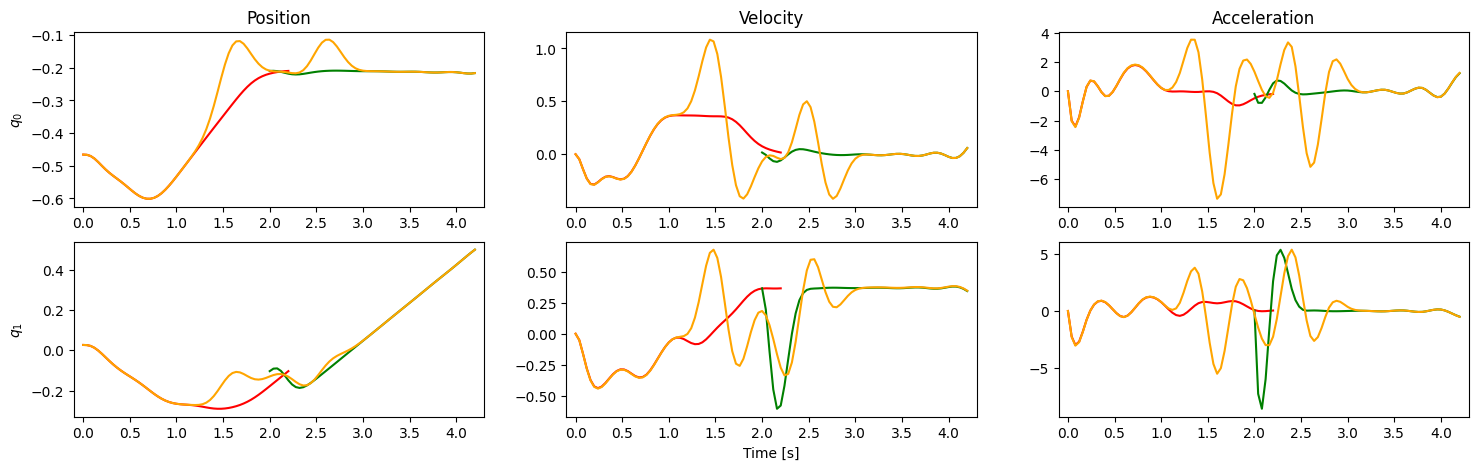

In [27]:
# plot merged cps
plt.close(fig)
device = "cuda:0"
device = get_torch_device(device)
tensor_args = {"device": device, "dtype": torch.float32}
q_trajs_merged_d = final_traj.get_q_trajectory_in_phase(merged_q_cps, get_type=("pos","vel","acc"))
scale = final_traj.phase_time.rs[0]
q_trajs_merged_pos = to_numpy(q_trajs_merged_d["pos"])
q_trajs_merged_vel = to_numpy(q_trajs_merged_d["vel"] * scale)
q_trajs_merged_acc = to_numpy(q_trajs_merged_d["acc"] * (scale * scale))
q_trajs_merged = (q_trajs_merged_pos, q_trajs_merged_vel, q_trajs_merged_acc)

q_trajs_pos_all = []
q_trajs_vel_all = []
q_trajs_acc_all = []
for i_hz in range(len(prob)) : 
    q_trajs_tmp_d = sml_traj.get_q_trajectory_in_phase(to_torch(q_cps_all[i_hz]), get_type=("pos","vel","acc"))        
    q_trajs_tmp_pos = q_trajs_tmp_d["pos"].unsqueeze(0)
    q_trajs_tmp_vel = (q_trajs_tmp_d["vel"]*sml_scale).unsqueeze(0)
    q_trajs_tmp_acc = (q_trajs_tmp_d["acc"]*sml_scale * sml_scale).unsqueeze(0)

    q_trajs_pos_all.append(q_trajs_tmp_pos)
    q_trajs_vel_all.append(q_trajs_tmp_vel)
    q_trajs_acc_all.append(q_trajs_tmp_acc)

q_trajs_pos_all = to_numpy(torch.cat(q_trajs_pos_all, axis = 0))
q_trajs_vel_all = to_numpy(torch.cat(q_trajs_vel_all, axis = 0))
q_trajs_acc_all = to_numpy(torch.cat(q_trajs_acc_all, axis = 0))
    
q_trajs_filtered = (q_trajs_pos_all, q_trajs_vel_all, q_trajs_acc_all)

fig, axs = plt.subplots(dim, 3, squeeze=False, figsize=(18, 2.5 * dim))

axs[0, 0].set_title("Position")
axs[0, 1].set_title("Velocity")
axs[0, 2].set_title("Acceleration")
axs[-1, 1].set_xlabel("Time [s]")

# h = 1.0 / (spline_l[-1].bspline.m - 2 * spline_l[-1].bspline.d)
# T = spline_l[-1].bspline.num_T_pts
# scale = spline_l[-1].phase_time.rs[0]
t_start = 0
t_goal = final_traj.trajectory_duration
print(final_traj.trajectory_duration)
#partial_dur * len(prob)
dt = sml_traj.trajectory_duration / (sml_traj.num_T_pts-1)

dt_merged = final_traj.trajectory_duration / (final_traj.num_T_pts-1)
# Positions, velocities, accelerations

offset = (sml_traj.trajectory_duration - 0.2) # 0.2 = 2*sml_traj.trajectory_duration - final_traj.trajectory-duration 
print(prob)
print(dt*sml_traj.num_T_pts)
for i, ax in enumerate(axs):
    for j, q_trajs_filtered_item in enumerate(q_trajs_filtered):
        for i_hz in range(len(prob)) :
            tmp_timesteps =  offset *(i_hz) + dt*(np.arange(sml_traj.num_T_pts))
            ax[j].plot(tmp_timesteps, q_trajs_filtered_item[i_hz,:,i], c = colors[i_hz], linestyle="solid")
        # plot merged spline
        tmp_timesteps = 0 + dt_merged*(np.arange(final_traj.num_T_pts))
        ax[j].plot(tmp_timesteps, q_trajs_merged[j][:,i], c = colors[-1], linestyle="solid")
    ax[0].set_ylabel(f"$q_{i}$")

t_eps = 0.1
for ax in list(itertools.chain(*axs)):
    ax.set_xlim(t_start - t_eps, t_goal + t_eps)



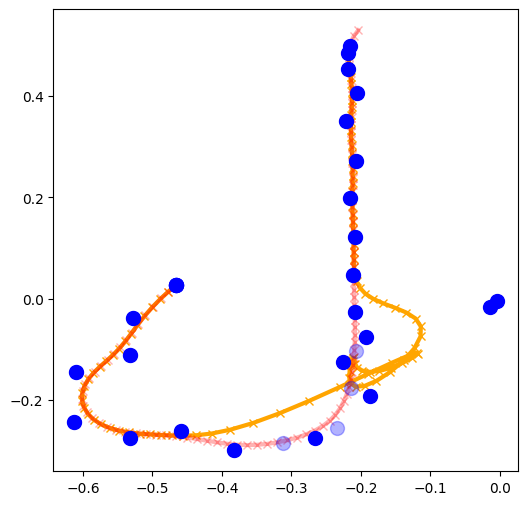

In [40]:
plt.close(fig)

# plot scatter 
fig_cps, axs_cps = create_fig_and_axes(2, figsize=(6, 6))
axs_cps.scatter(merged_q_cps[:,0], merged_q_cps[:,1], c="blue", marker="o", s=10**2, zorder=100)
axs_cps.scatter(ans_spline.c[:20,0], ans_spline.c[:20,1], c="blue", marker="o", s=10**2, zorder=109, alpha=0.3) # ground truth control point 

ref_traj = to_numpy(q_trajs_pos_ref[0])
axs_cps.plot(q_trajs_merged[0][:, 0], q_trajs_merged[0][:, 1], color="orange", linestyle="solid", linewidth=3, marker="x")
axs_cps.plot(ref_traj[:100, 0], ref_traj[:100, 1], color="red", linestyle="solid", linewidth=3, marker="x", alpha=0.3) # ground truth 